# prep.cooccurrence

Cooccurrence analysis are computed in R. In this notebook, we convert data processed previously in `prep.motus` and `prep.virus` to generate the codetection matrices that are necessary to run those analysis. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()

┌─────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│          name           │                                                                                  description                                                                                   │
│         varchar         │                                                                                    varchar                                                                                     │
├─────────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_sites                 │ This table contains key information about each of the libraries, such as their site, habitat and host                                                   

The strategy will be the following one: 

1. Loading the files (separately)
2. Create a de-duplicated table
3. Pivot the table to generate a row-OTU library-column detection matrix
4. Merge the two tables together. 

## Step 1:  Load files

We have to use the `use_pab=True` option to run this analysis only on PAB bacteria.

In [2]:
bacteria_hits = db.conn.sql('SELECT * FROM D_PABHits').df()
virus_hits = db.conn.sql('SELECT * FROM D_virusHits').df()
# bacteria_hits = pd.read_csv("output/hits.bacteria.csv", sep=";").query('is_pab == True')
# virus_hits = pd.read_csv("output/hits.virus.csv", sep=";")


## Step 2: Deduplicate

In principle, we should have duplicates, so this step could be avoided. #TODO

In [3]:
virus_hits_pvt = virus_hits.drop_duplicates(subset=['scientific_name', 'library'], keep='first')
bacteria_hits_pvt = bacteria_hits.drop_duplicates(subset=['scientific_name', 'library'], keep='first')

## Step 3: Pivot

We will visualize the heatmaps to check that everything is in order. 

We generate a column `foo` with value 1 to do the pivot; the cooccurence analysis is not dependent on the weight of the system.

<Axes: xlabel='library', ylabel='scientific_name'>

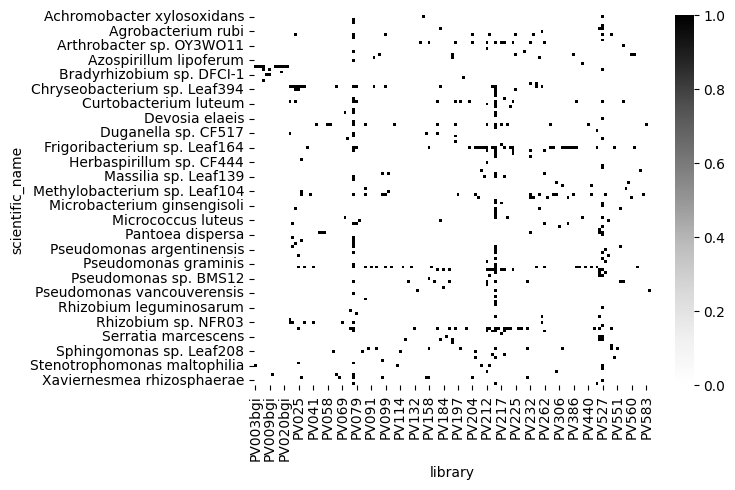

In [4]:
bacteria_hits_pvt['foo'] = 1
bacteria_hits_pvt = bacteria_hits_pvt.pivot(index='scientific_name', columns='library', values='foo').fillna(0)
sns.heatmap(bacteria_hits_pvt, cmap='Grays')

<Axes: xlabel='library', ylabel='scientific_name'>

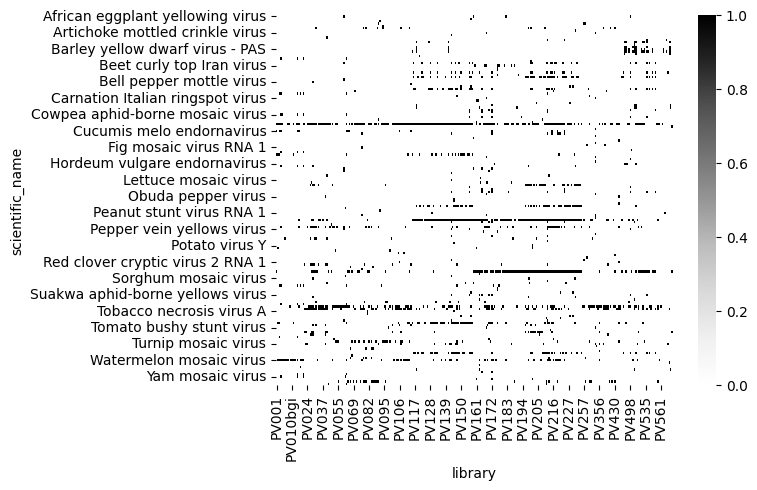

In [5]:


virus_hits_pvt['foo'] = 1
virus_hits_pvt = virus_hits_pvt.pivot(index='scientific_name', columns='library', values='foo').fillna(0)
sns.heatmap(virus_hits_pvt, cmap='Grays')

## Step 4: concat and save 

In [6]:
M = pd.concat([virus_hits_pvt, bacteria_hits_pvt]).fillna(0)
assert(len(M) == 158 + 127) # To check that we have the same number of bacteria  virus
M.to_csv("scratch/adjmat.virusbact-library.csv", sep=';')

In [7]:
db.conn.close()